Author: Derrick Chen (format based on a project by Anna Phyo & Derrick Chen)

> Add blockquote



Date: 06/15/2026

Modified Date: 07/29/2026

Description: This file contains the fully functional codes to train a water quality predicting model using Logistic Regression, AdaBoost, Gradient Boosting Classifier, Random Forest, Stochastic Gradient Descent (SGD) Classifier, Linear Support Vector Classifier (SVC), Artificial Neural Network (ANN)/Multilayer Perceptrion (MLP), and the K-Nearest Neighbors (KNN) algorithms. Code includes data fitting, training, and results analysis.

1. Importing the File

In [ ]:
import pandas as pd

# Mounting the Drive
from google.colab import drive
drive.mount('/content/drive')

# Pathing to my file
file = "/content/drive/MyDrive/water_potability.csv"

Mounted at /content/drive


2. Reading the File

In [ ]:
df = pd.read_csv(file)

3. Using Three Methods to Explore the Data

In [ ]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [ ]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


4. Plotting A Histogram for Each Numerical Attribute

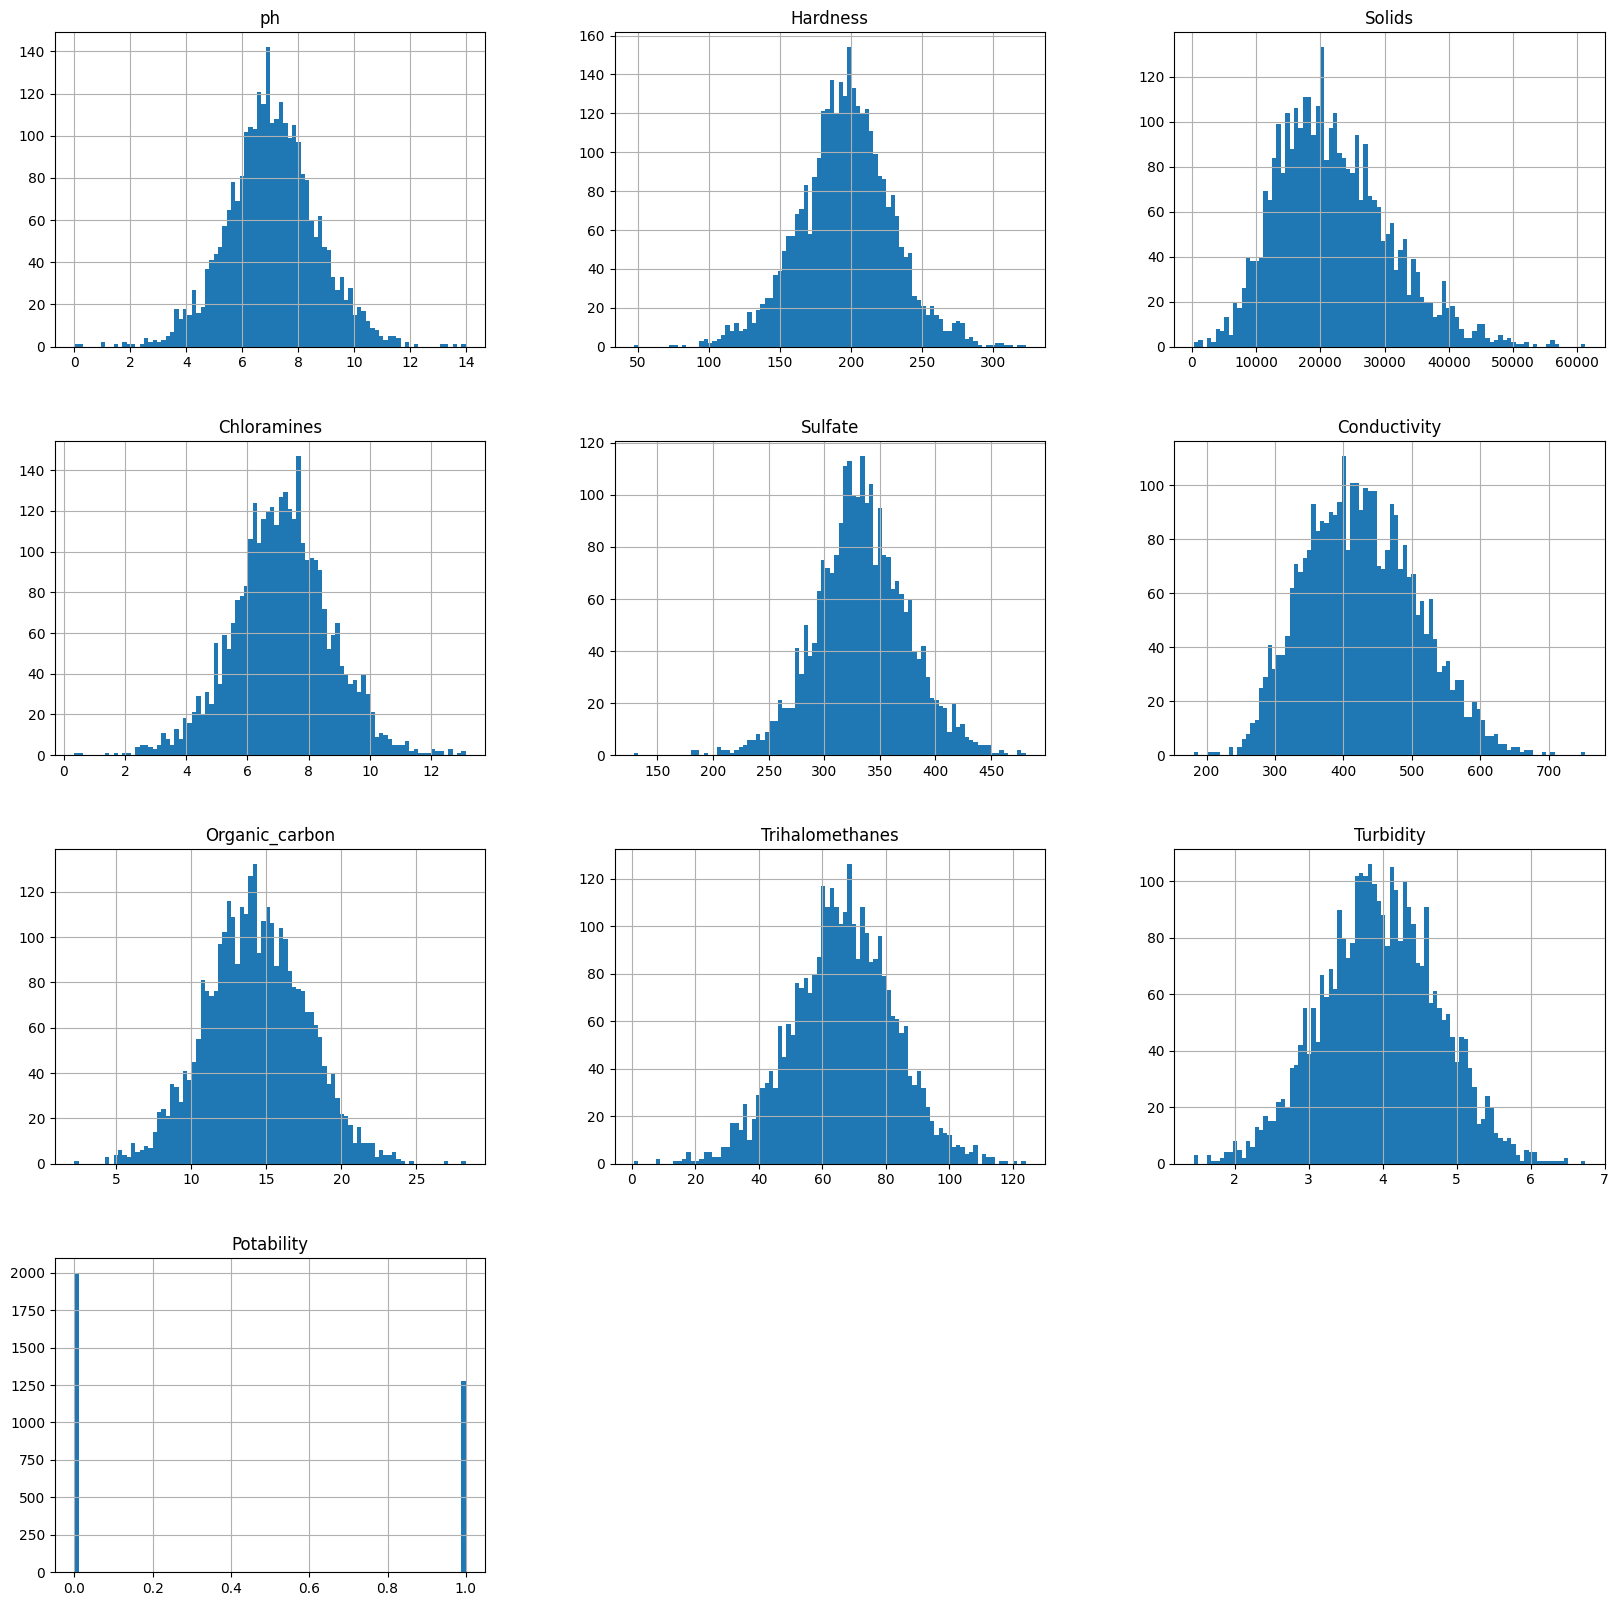

In [ ]:
import matplotlib.pyplot as plt

df.hist(bins=90, figsize=(20, 20))
plt.show()

Observations: Potability is the main focus as that's what determines if the water is potable or not, measured as 1 for potable and 0 for not, though there are more values listed as not potable. The 9 predictors all have similar trends where the values are highest around the center of their graphs or close to it, between 0 and their respective highest values in rough bell shapes and mostly normal distributions. Solids is slightly skewed to the right

5. Plotting the Feature Correlation Matrix

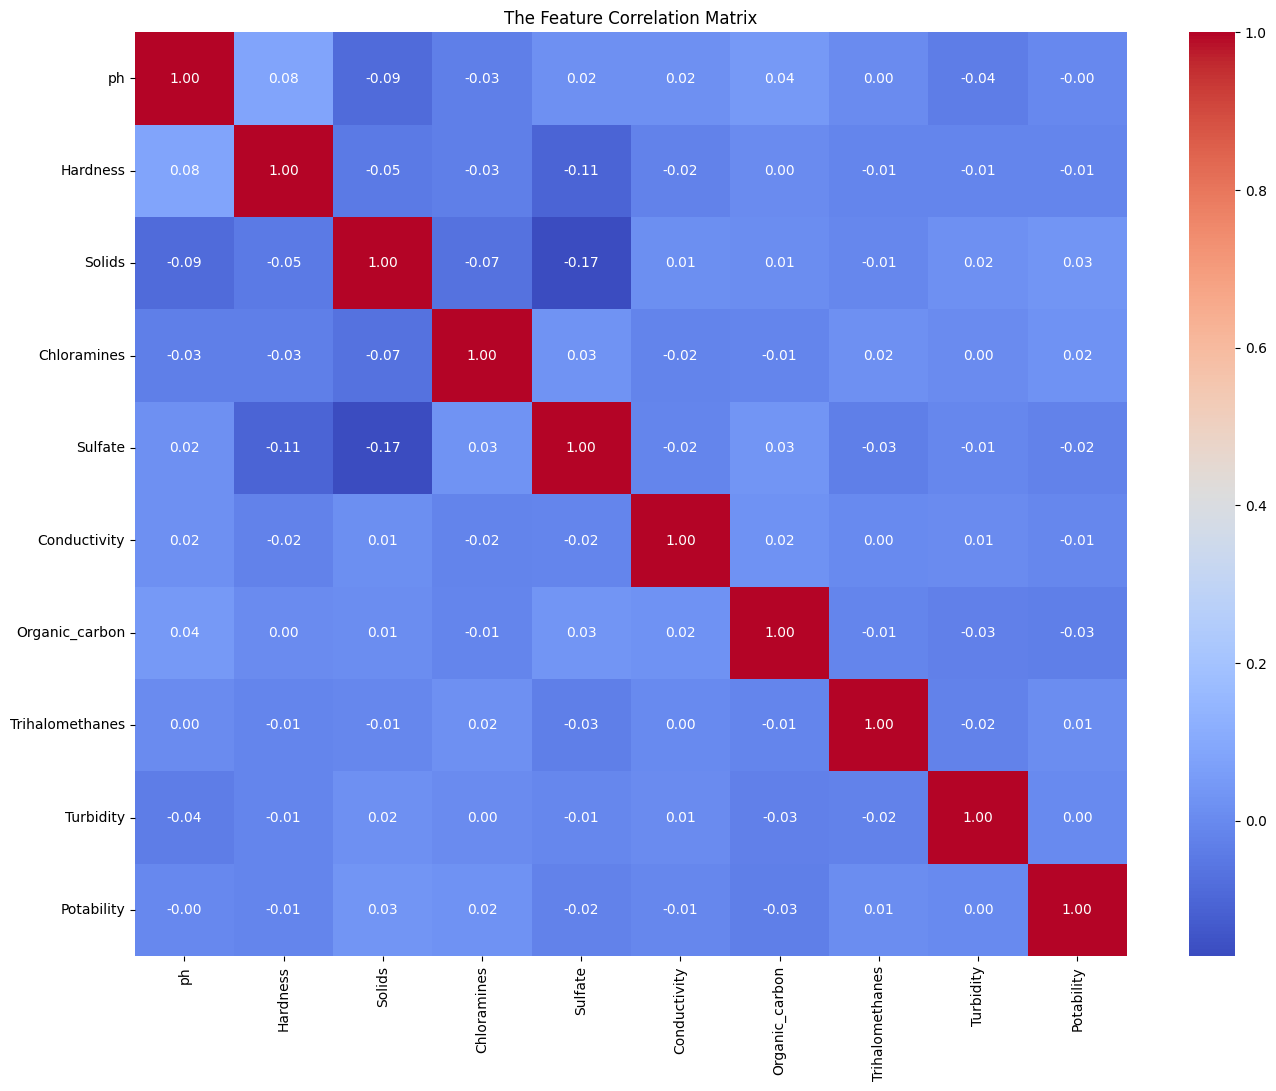

Correlations with potability:
 Potability         1.000000
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Conductivity      -0.008128
Hardness          -0.013837
Sulfate           -0.023577
Organic_carbon    -0.030001
Name: Potability, dtype: float64

Top 5 positively correlated features with potability:
Solids             0.033743
Chloramines        0.023779
Trihalomethanes    0.007130
Turbidity          0.001581
ph                -0.003556
Name: Potability, dtype: float64

Top 5 negatively correlated features with potability:
ph               -0.003556
Conductivity     -0.008128
Hardness         -0.013837
Sulfate          -0.023577
Organic_carbon   -0.030001
Name: Potability, dtype: float64


In [ ]:
import seaborn as sns

# Keep only numeric columns
df_numeric = df.select_dtypes(include=['float64', 'int64'])

# Compute correlations
correlation_matrix = df_numeric.corr()

# Heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("The Feature Correlation Matrix")
plt.show()

# Correlation with potability
target_corr = correlation_matrix['Potability'].sort_values(ascending=False)
print("Correlations with potability:\n", target_corr)

# Top 5 positive and negative correlations for potability
print("\nTop 5 positively correlated features with potability:")
print(target_corr[1:6])  # skip self-correlation

print("\nTop 5 negatively correlated features with potability:")
print(target_corr[-5:])

Observations:

Top positive correlations:

- Potability has weak positive correlations with solids, chloramines, trihalometanes, and turbidity

Top negative correlations:

- Potability has weak negative correlations with pH, conductivity, hardness, sulfate, and organic_carbon

Since potability is measured in 0 or 1, correlations will be difficult to interpret with them being this weak

6.Comparing potable vs non potable samples

In [ ]:
df.groupby('Potability').agg(['mean', 'median', 'std'])

ph                        Hardness                         \
                mean    median       std        mean      median        std   
Potability                                                                    
0           7.085378  7.035456  1.683499  196.733292  197.123423  31.057540   
1           7.073783  7.036752  1.448048  195.800744  196.632907  35.547041   

                  Solids                            Chloramines  ...  \
                    mean        median          std        mean  ...   
Potability                                                       ...   
0           21777.490788  20809.618280  8543.068788    7.092175  ...   
1           22383.991018  21199.386614  9101.010208    7.169338  ...   

           Conductivity Organic_carbon                      Trihalomethanes  \
                    std           mean     median       std            mean   
Potability                                                                    
0             80.047317      14.364335  14.293508  3.334554       66.303555   
1             82.048446      14.160893  14.162809  3.263907       66.539684   

                                 Turbidity                      
               median        std      mean    median       std  
Potability                                                      
0           66.542198  16.079320  3.965800  3.948076  0.780282  
1           66.678214  16.327419  3.968328  3.958576  0.780842  

[2 rows x 27 columns]

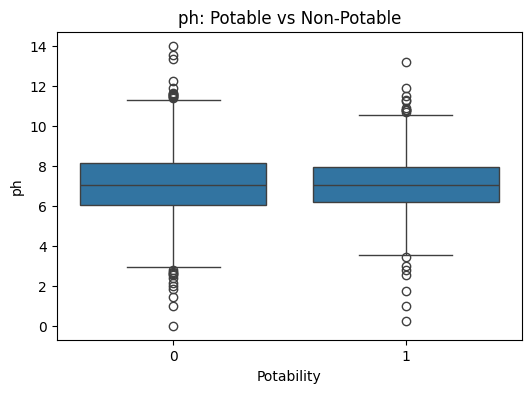

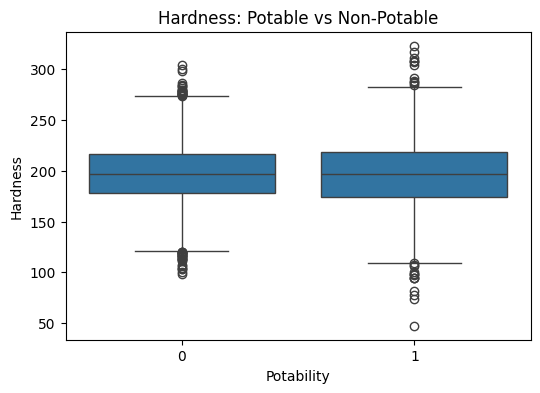

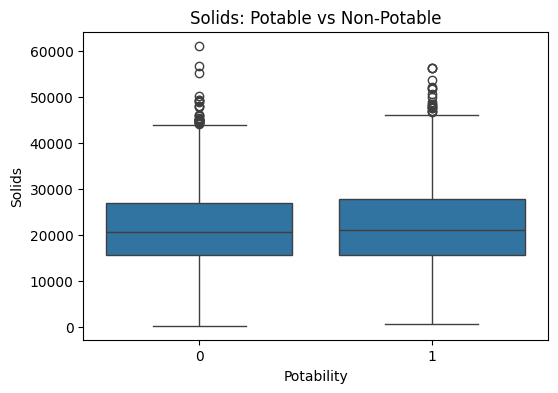

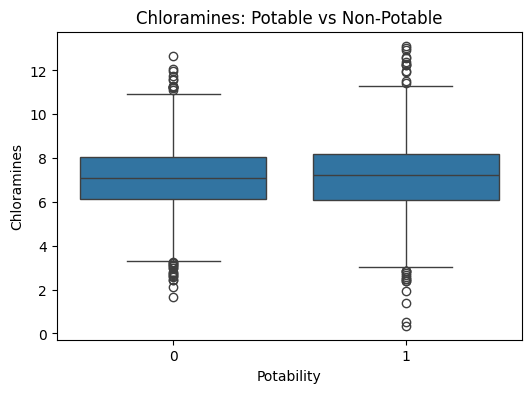

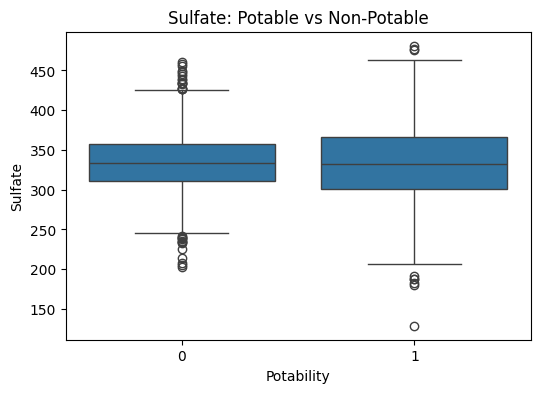

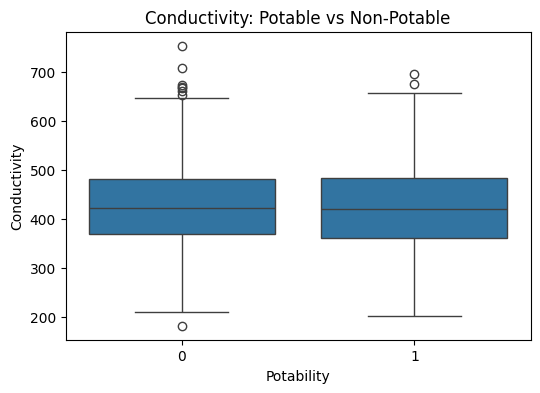

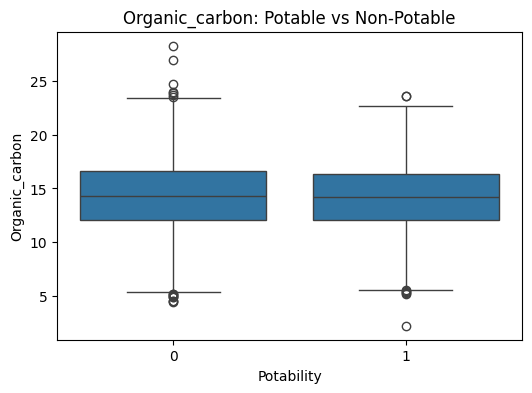

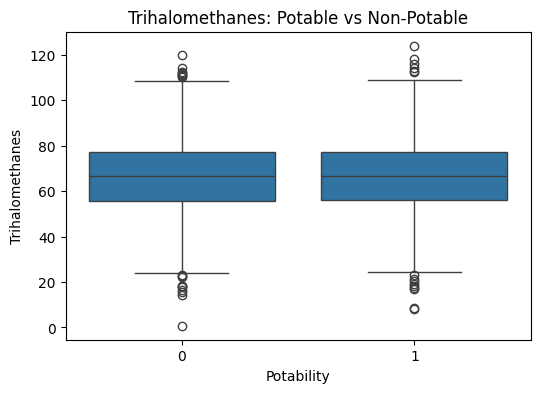

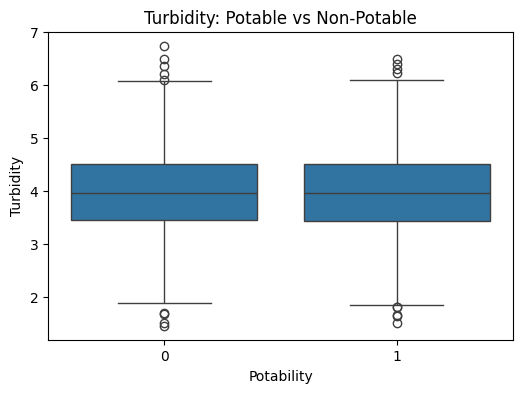

In [ ]:
features = df.columns.drop('Potability')

for feature in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Potability', y=feature, data=df)
    plt.title(f'{feature}: Potable vs Non-Potable')
    plt.show()

Observations: potable water tends to have pH closer to 7 as that's the ideal pH, generally lower sulfate levels, lower organic carbon and conductivity. Potability tends to have a narrower range of values that non-potability tends to go past, but it's not always the case.

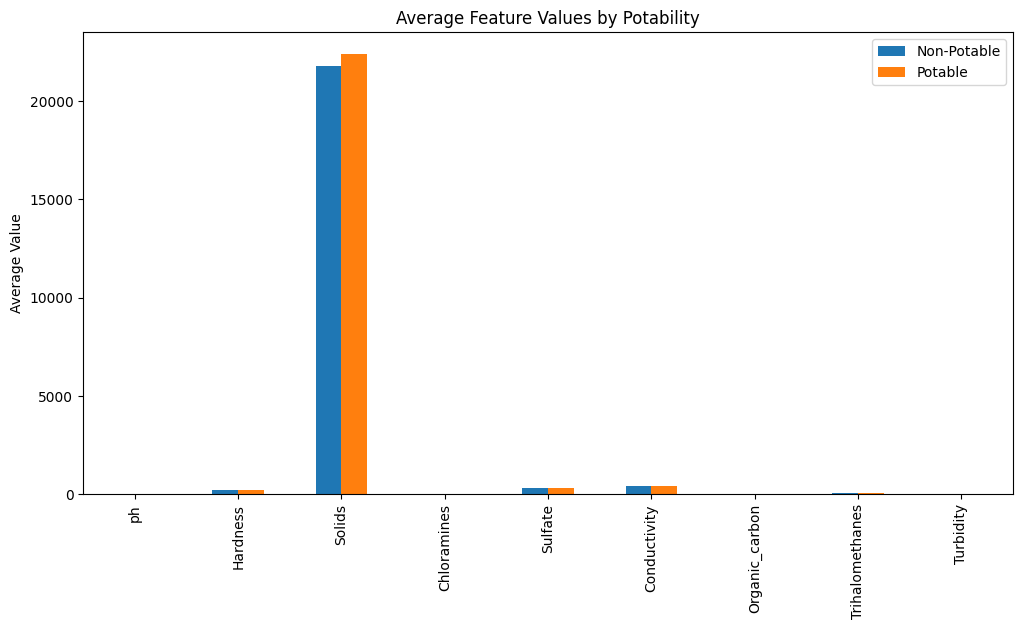

In [ ]:
#Graph Comparison
comparison = df.groupby('Potability').mean().T

comparison.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Average Feature Values by Potability')
plt.ylabel('Average Value')
plt.legend(['Non-Potable', 'Potable'])

plt.show()

In [ ]:
#Significance Test
from scipy.stats import ttest_ind

for col in df.columns[:-1]:
    potable = df[df['Potability'] == 1][col].dropna()
    non_potable = df[df['Potability'] == 0][col].dropna()

    stat, p = ttest_ind(potable, non_potable)

    print(f"{col}: p-value = {p:.4f}")

ph: p-value = 0.8512
Hardness: p-value = 0.4285
Solids: p-value = 0.0535
Chloramines: p-value = 0.1736
Sulfate: p-value = 0.2391
Conductivity: p-value = 0.6419
Organic_carbon: p-value = 0.0860
Trihalomethanes: p-value = 0.6908
Turbidity: p-value = 0.9279


7. Feature Engineering

In [ ]:
#Missing value input
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
df[df.columns[:-1]] = imputer.fit_transform(df[df.columns[:-1]])

In [ ]:
#Interaction features
df['Solids_x_Conductivity'] = (df['Solids'] * df['Conductivity'])

#Ratio features
df['Hardness_to_Sulfate'] = (df['Hardness'] / df['Sulfate'])

#pH categories
df['ph_acidic'] = (df['ph'] < 6.5).astype(int)
df['ph_basic'] = (df['ph'] > 8.5).astype(int)

# Drop NaNs
df = df.dropna()

8. Splitting Datasets into Training, Validation and Test Sets

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Potability', axis=1)
y = df['Potability']
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

9. Separating Features and Target

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

10. Checking Whether the Training Set Has the Correct Features

In [ ]:
print(X.columns)

Index(['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity',
       'Organic_carbon', 'Trihalomethanes', 'Turbidity',
       'Solids_x_Conductivity', 'Hardness_to_Sulfate', 'ph_acidic',
       'ph_basic'],
      dtype='object')


11. Scaling Features for Logistic Regression and Support Vector Machine (SVM)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

12. Training the Model Using Logistic Regression for predicting outcome probabilities

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Logistic Regression ===")

for name, (X_set, y_set) in datasets.items():
    log_pred = log_model.predict(X_set)

    log_accuracy = accuracy_score(y_set, log_pred)
    log_f1 = f1_score(y_set, log_pred)

    print(f"\n{name}")
    print(f"Accuracy : {log_accuracy:.4f}")
    print(f"F1 Score : {log_f1:.4f}")

=== Logistic Regression ===

Train
Accuracy : 0.6097
F1 Score : 0.0543

Validation
Accuracy : 0.6214
F1 Score : 0.0606

Test
Accuracy : 0.6052
F1 Score : 0.0443


Observations: At a first impression, the model had accurate predictions only about 60% of the time across all 3 datasets with an F1 score ranging from 0.04-0.06, which is not a good look so far. It could mean the dataset is a bit small, something wasn't set up properly, or I just messed up.

Logistic Regression Optimization

In [ ]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
log_param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'solver': ['liblinear', 'lbfgs'], 'penalty': ['l2']}

# Initialize the model
logO = LogisticRegression(max_iter=1000, random_state=42)

# Grid Search with 5-fold cross-validation
log_grid_search = GridSearchCV( estimator=logO, param_grid=log_param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit using the training data only
log_grid_search.fit(X_train, y_train)

print("Best Parameters:", log_grid_search.best_params_)
print("Best Cross-Validation F1 Score:", log_grid_search.best_score_)

Best Parameters: {'C': 100, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Cross-Validation F1 Score: 0.0888780378267909


In [ ]:
log_modelO = log_grid_search.best_estimator_
log_modelO.fit(X_train, y_train)

datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Logistic Regression Optimized ===")

for name, (X_set, y_set) in datasets.items():
    logO_pred = log_modelO.predict(X_set)

    logO_accuracy = accuracy_score(y_set, logO_pred)
    logO_f1 = f1_score(y_set, logO_pred)

    print(f"\n{name}")
    print(f"Accuracy : {logO_accuracy:.4f}")
    print(f"F1 Score : {logO_f1:.4f}")

=== Logistic Regression Optimized ===

Train
Accuracy : 0.6097
F1 Score : 0.0658

Validation
Accuracy : 0.6229
F1 Score : 0.0749

Test
Accuracy : 0.6067
F1 Score : 0.0515


Observations:
Optimization only increased the F1 Score by the hundredths which is barely an improvement. There could be something wrong with the data but for now I'll continue testing models.

Training the Optimized AdaBoosting Classifier


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import GridSearchCV

ada_param_grid = {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.5, 1.0]}

ada_grid_search = GridSearchCV(AdaBoostClassifier(random_state=42), ada_param_grid, cv=5, scoring='f1', n_jobs=-1)

ada_grid_search.fit(X_train, y_train)

print("Best Parameters:", ada_grid_search.best_params_)
print("Best Cross-Validation F1:", ada_grid_search.best_score_)

Best Parameters: {'learning_rate': 1.0, 'n_estimators': 200}
Best Cross-Validation F1: 0.19525275807678127


In [ ]:
# Create and train the AdaBoost model
ada_model = ada_grid_search.best_estimator_

ada_model.fit(X_train, y_train)

# Evaluate on Train, Validation, and Test sets
datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== AdaBoost Classifier ===")

for name, (X_set, y_set) in datasets.items():
    ada_pred = ada_model.predict(X_set)

    ada_accuracy = accuracy_score(y_set, ada_pred)
    ada_f1 = f1_score(y_set, ada_pred)

    print(f"\n{name}")
    print(f"Accuracy : {ada_accuracy:.4f}")
    print(f"F1 Score : {ada_f1:.4f}")

=== AdaBoost Classifier ===

Train
Accuracy : 0.6366
F1 Score : 0.2119

Validation
Accuracy : 0.6244
F1 Score : 0.1800

Test
Accuracy : 0.6204
F1 Score : 0.1836


Observations: AdaBoost optimized with GridSearch had about the same accuracy as Logistic Regression but while F1 Scores were significantly higher, they were still considered very poor.

Checking Class Balance for Gradient Boosting Classificaiton

In [ ]:
# Check class distribution
print(y_train.value_counts())

# Percentage of each class
print(y_train.value_counts(normalize=True) * 100)

Potability
0    1198
1     767
Name: count, dtype: int64
Potability
0    60.966921
1    39.033079
Name: proportion, dtype: float64


Training the GradientBoosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gbc_model = GradientBoostingClassifier(random_state=42)

gbc_model.fit(X_train, y_train)

datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Gradient Boosting ===")

for name, (X_set, y_set) in datasets.items():
    gbc_pred = gbc_model.predict(X_set)

    gbc_accuracy = accuracy_score(y_set, gbc_pred)
    gbc_f1 = f1_score(y_set, gbc_pred)

    print(f"\n{name}")
    print(f"Accuracy : {gbc_accuracy:.4f}")
    print(f"F1 Score : {gbc_f1:.4f}")

=== Gradient Boosting ===

Train
Accuracy : 0.7730
F1 Score : 0.6074

Validation
Accuracy : 0.6412
F1 Score : 0.3343

Test
Accuracy : 0.6494
F1 Score : 0.3575


Observations:
Gradient Boosting had moderately good scores for accuracy and F1 score, but fell off for the validation and test sets showing overfitting. The test F1 score is still higher than the next best score (0.35375 > 0.1836) but still poor.

13. Training the Model Using the Random Forest to Handle Complex and Non-linear Relationships

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=15, min_samples_leaf=2, random_state=42)

rf_model.fit(X_train, y_train)

datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Random Forest ===")

for name, (X_set, y_set) in datasets.items():
    rf_pred = rf_model.predict(X_set)

    rf_accuracy = accuracy_score(y_set, rf_pred)
    rf_f1 = f1_score(y_set, rf_pred)

    print(f"\n{name}")
    print(f"Accuracy : {rf_accuracy:.4f}")
    print(f"F1 Score : {rf_f1:.4f}")

=== Random Forest ===

Train
Accuracy : 0.9613
F1 Score : 0.9479

Validation
Accuracy : 0.6656
F1 Score : 0.3967

Test
Accuracy : 0.6585
F1 Score : 0.3846


Observations: The model performed perfectly on accuracy and F1 score for trainin, but just like Gradient Boost it greatly decreased for validation and test datasets to mediocre values for accuracy and less than average for F1. AFter limiting tree complexity, train accuracy and F1 went down a little bit, accuracy for the others were slightly lower and F1 seen noticable but not too drastic drops.

14. Training the Model Using the Stochastic Gradient Descent (SGD) Classifier

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(loss='log_loss', max_iter=1000, random_state=42) # Logistic Regression using SGD

sgd_model.fit(X_train, y_train)

# Evaluate on Train, Validation, and Test sets
datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Stochastic Gradient Descent ===")

for name, (X_set, y_set) in datasets.items():
    sgd_pred = sgd_model.predict(X_set)

    sgd_accuracy = accuracy_score(y_set, sgd_pred)
    sgd_f1 = f1_score(y_set, sgd_pred)

    print(f"\n{name}")
    print(f"Accuracy : {sgd_accuracy:.4f}")
    print(f"F1 Score : {sgd_f1:.4f}")

=== Stochastic Gradient Descent ===

Train
Accuracy : 0.5272
F1 Score : 0.3659

Validation
Accuracy : 0.5038
F1 Score : 0.3539

Test
Accuracy : 0.5366
F1 Score : 0.3968


Observations: Performance is moderate but clearly worse than the other models with accuracy not being much better than random guessing at around 0.5 and low f1 score.

SGD Classifier Optimization (Alpha and Penalities)

In [ ]:
sgd_param_grid = {'loss': ['hinge', 'log_loss', 'modified_huber'], 'alpha': [0.0001, 0.001, 0.01], 'penalty': ['l2', 'l1', 'elasticnet'], 'max_iter': [1000, 2000]}

sgdO = SGDClassifier(random_state=42)

# Grid Search
sgd_grid_search = GridSearchCV(estimator=sgdO, param_grid=sgd_param_grid, cv=5, scoring='f1', n_jobs=-1)

sgd_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(sgd_grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(f"{sgd_grid_search.best_score_:.4f}")

Best Parameters:
{'alpha': 0.0001, 'loss': 'modified_huber', 'max_iter': 1000, 'penalty': 'l2'}

Best Cross-Validation F1 Score:
0.3907


In [ ]:
sgdO_model =sgd_grid_search.best_estimator_

sgdO_model.fit(X_train, y_train)

sgdO_datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Optimized SGD Classifier ===")

for name, (X_set, y_set) in datasets.items():
    sgdO_pred = sgdO_model.predict(X_set)

    sgdO_accuracy = accuracy_score(y_set, sgdO_pred)
    sgdO_f1 = f1_score(y_set, sgdO_pred)

    print(f"\n{name}")
    print(f"Accuracy : {sgdO_accuracy:.4f}")
    print(f"F1 Score : {sgdO_f1:.4f}")

=== Optimized SGD Classifier ===

Train
Accuracy : 0.5674
F1 Score : 0.3390

Validation
Accuracy : 0.5832
F1 Score : 0.3666

Test
Accuracy : 0.5762
F1 Score : 0.3535


Observations:

GridSearch optimization hardly improved accuracy and F1 scores, so I'm starting to think I have bad data. Unfortunately, it's a bit too late to pivot datasets since it's already July and I want to test 3 datasets.

16. Training the Model Using the Linear Support Vector Classifier (SVC)

In [ ]:
from sklearn.svm import LinearSVC, SVC

svc_model = SVC(random_state=42)

svc_model.fit(X_train, y_train)

svc_datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Support Vector Machine ===")

for name, (X_set, y_set) in datasets.items():
    svc_pred = svc_model.predict(X_set)

    svc_accuracy = accuracy_score(y_set, svc_pred)
    svc_f1 = f1_score(y_set, svc_pred)

    print(f"\n{name}")
    print(f"Accuracy : {svc_accuracy:.4f}")
    print(f"F1 Score : {svc_f1:.4f}")

=== Support Vector Machine ===

Train
Accuracy : 0.7338
F1 Score : 0.5197

Validation
Accuracy : 0.6824
F1 Score : 0.4057

Test
Accuracy : 0.6555
F1 Score : 0.3616


Observations: The model's overall accuracy is decent but test F1 score remains low which is just like random forest. Validation and test scores all went down compared to train, so my suspicion that the dataset is too small to have proper training might be true after all.

Linear SVC Optimization

In [ ]:
svc_param_grid = {'C': [0.01, 0.1, 1, 10, 100], 'loss': ['hinge', 'squared_hinge']}

# Create LinearSVC model
linear_svc = LinearSVC(random_state=42, dual="auto", max_iter=10000)

# Perform Grid Search
svc_grid_search = GridSearchCV(estimator=linear_svc, param_grid=svc_param_grid, cv=5, scoring='f1', n_jobs=-1)

svc_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(svc_grid_search.best_params_)

print(f"\nBest Cross-Validation F1 Score: {svc_grid_search.best_score_:.4f}")

Best Parameters:
{'C': 10, 'loss': 'squared_hinge'}

Best Cross-Validation F1 Score: 0.0831


In [ ]:
svcO_model = svc_grid_search.best_estimator_

svcO_model.fit(X_train, y_train)

svcO_datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Optimized LinearSVC ===")

for name, (X_set, y_set) in datasets.items():
    svcO_pred = svcO_model.predict(X_set)

    svcO_accuracy = accuracy_score(y_set, svcO_pred)
    svcO_f1 = f1_score(y_set, svcO_pred)

    print(f"\n{name}")
    print(f"Accuracy : {svcO_accuracy:.4f}")
    print(f"F1 Score : {svcO_f1:.4f}")

=== Optimized LinearSVC ===

Train
Accuracy : 0.6087
F1 Score : 0.0611

Validation
Accuracy : 0.6244
F1 Score : 0.0752

Test
Accuracy : 0.6067
F1 Score : 0.0515


Observations:

Hyperparameter tuning somehow made the accuracy worse and made the F1 score near zero and accuracy near 0.6

17. Training the Model Using the Artificial Neural Network (ANN), the  Multi-layer Perceptron (MLP) Regressor

In [ ]:
from sklearn.neural_network import MLPClassifier

ann_param_grid = {'hidden_layer_sizes': [(50,), (100,), (100, 50)], 'activation': ['relu'], 'alpha': [0.0001, 0.001], 'learning_rate_init': [0.001], 'solver': ['adam', 'lbfgs'],'max_iter': [500, 1000]}

mlp = MLPClassifier(random_state=42, early_stopping=True, validation_fraction=0.1)

# Grid Search
ann_grid_search = GridSearchCV(estimator=mlp, param_grid=ann_param_grid, cv=5, scoring='f1', n_jobs=-1)

ann_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(ann_grid_search.best_params_)

print(f"\nBest Cross-Validation F1 Score: {ann_grid_search.best_score_:.4f}")

Best Parameters:
{'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate_init': 0.001, 'max_iter': 500, 'solver': 'lbfgs'}

Best Cross-Validation F1 Score: 0.5210


In [ ]:
ann_model = ann_grid_search.best_estimator_

ann_model.fit(X_train, y_train)

ann_datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== Artificial Neural Network (MLP) ===")

for name, (X_set, y_set) in ann_datasets.items():

    ann_pred = ann_model.predict(X_set)

    ann_accuracy = accuracy_score(y_set, ann_pred)
    ann_f1 = f1_score(y_set, ann_pred)

    print(f"\n{name}")
    print(f"Accuracy : {ann_accuracy:.4f}")
    print(f"F1 Score : {ann_f1:.4f}")

=== Artificial Neural Network (MLP) ===

Train
Accuracy : 1.0000
F1 Score : 1.0000

Validation
Accuracy : 0.6153
F1 Score : 0.5154

Test
Accuracy : 0.5899
F1 Score : 0.4953


Observation: A smaller ANN model for run time purposes has moderate test scores, a bigger one would likely have higher scores

18. Training the Model with K Nearest Neighbors (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_param_grid = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance'], 'metric': ['euclidean', 'manhattan']}

# Create the KNN model
knn = KNeighborsClassifier()

# Perform Grid Search
knn_grid_search = GridSearchCV(estimator=knn, param_grid=knn_param_grid, cv=5, scoring='f1', n_jobs=-1)

knn_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(knn_grid_search.best_params_)

print(f"\nBest Cross-Validation F1 Score: {knn_grid_search.best_score_:.4f}")

Best Parameters:
{'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}

Best Cross-Validation F1 Score: 0.4697


In [ ]:
knn_model = knn_grid_search.best_estimator_

knn_model.fit(X_train, y_train)

knn_datasets = {"Train": (X_train, y_train), "Validation": (X_val, y_val), "Test": (X_test, y_test)}

print("=== K-Nearest Neighbors ===")

for name, (X_set, y_set) in datasets.items():
    knn_pred = knn_model.predict(X_set)

    knn_accuracy = accuracy_score(y_set, knn_pred)
    knn_f1 = f1_score(y_set, knn_pred)

    print(f"\n{name}")
    print(f"Accuracy : {knn_accuracy:.4f}")
    print(f"F1 Score : {knn_f1:.4f}")

=== K-Nearest Neighbors ===

Train
Accuracy : 1.0000
F1 Score : 1.0000

Validation
Accuracy : 0.6031
F1 Score : 0.4515

Test
Accuracy : 0.5869
F1 Score : 0.3937


Observations:

- KNN had slightly lower performance than ANN, and was able to get perfect scores on the train datasets. However, the trend for validation and test scores being much lower still persists.


19. Calculating Error Rates for all Models

In [ ]:
models_list = {
    "Logistic Regression": log_model,
    "Logistic Regression Optimized": log_modelO,
    "AdaBoost": ada_model,
    "Gradient Boosting": gbc_model,
    "Random Forest": rf_model,
    "SGD": sgd_model,
    "SGD Optimized": sgdO_model,
    "Linear SVC": svc_model,
    "Linear SVC Optimized": svcO_model,
    "ANN/MLP": ann_model,
    "KNN": knn_model
}

model_results = []

for name, model in models_list.items():

    list_pred = model.predict(X_test)

    list_accuracy = accuracy_score(y_test, list_pred)
    error_rate = (1 - list_accuracy) * 100

    model_results.append({
        "Model": name,
        "Accuracy (%)": list_accuracy * 100,
        "Error Rate (%)": error_rate
    })

results_df = pd.DataFrame(model_results)

print(results_df.sort_values(by="Accuracy (%)", ascending=False))

                            Model  Accuracy (%)  Error Rate (%)
4                   Random Forest     65.853659       34.146341
7                      Linear SVC     65.548780       34.451220
3               Gradient Boosting     64.939024       35.060976
2                        AdaBoost     62.042683       37.957317
1   Logistic Regression Optimized     60.670732       39.329268
8            Linear SVC Optimized     60.670732       39.329268
0             Logistic Regression     60.518293       39.481707
9                         ANN/MLP     58.993902       41.006098
10                            KNN     58.689024       41.310976
6                   SGD Optimized     57.621951       42.378049
5                             SGD     53.658537       46.341463


20. Printing the Precision and Recall Scores for the Models

In [ ]:
from sklearn.metrics import precision_score, recall_score

pr_model_list = {
    "Logistic Regression": log_model,
    "Logistic Regression Optimized": log_modelO,
    "AdaBoost": ada_model,
    "Gradient Boosting": gbc_model,
    "Random Forest": rf_model,
    "SGD": sgd_model,
    "SGD Optimized": sgdO_model,
    "Linear SVC": svc_model,
    "Linear SVC Optimized": svcO_model,
    "ANN/MLP": ann_model,
    "KNN": knn_model
}

pr_results = []

for name, model in pr_model_list.items():

    # Predictions on the test set
    pr_pred = model.predict(X_test)

    # Calculate metrics
    precision = precision_score(y_test, pr_pred)
    recall = recall_score(y_test, pr_pred)

    pr_results.append({
        "Model": name,
        "Precision": precision,
        "Recall": recall
    })

# Display results
results_df = pd.DataFrame(pr_results)

print(results_df.sort_values(by="Precision", ascending=False))

                            Model  Precision    Recall
7                      Linear SVC   0.653061  0.250000
4                   Random Forest   0.648148  0.273438
3               Gradient Boosting   0.627451  0.250000
2                        AdaBoost   0.571429  0.109375
9                         ANN/MLP   0.476534  0.515625
10                            KNN   0.460733  0.343750
1   Logistic Regression Optimized   0.437500  0.027344
8            Linear SVC Optimized   0.437500  0.027344
6                   SGD Optimized   0.436782  0.296875
5                             SGD   0.403226  0.390625
0             Logistic Regression   0.400000  0.023438


21. Final Comparison Table for Accuracy, F1, Error Rate, Precision, and Recall

In [ ]:
final_model_list = {
    "Logistic Regression": log_model,
    "Logistic Regression Optimized": log_modelO,
    "AdaBoost": ada_model,
    "Gradient Boosting": gbc_model,
    "Random Forest": rf_model,
    "SGD": sgd_model,
    "SGD Optimized": sgdO_model,
    "Linear SVC": svc_model,
    "Linear SVC Optimized": svcO_model,
    "ANN/MLP": ann_model,
    "KNN": knn_model
}

final_results = []

for name, model in final_model_list.items():

    final_pred = model.predict(X_test)

    final_accuracy = accuracy_score(y_test, final_pred)
    final_precision = precision_score(y_test, final_pred)
    final_recall = recall_score(y_test, final_pred)
    final_f1 = f1_score(y_test, final_pred)
    final_error = (1 - final_accuracy) * 100

    final_results.append({
        "Model": name,
        "Accuracy (%)": final_accuracy * 100,
        "Error Rate (%)": final_error,
        "Precision": final_precision,
        "Recall": final_recall,
        "F1 Score": final_f1
    })

results_df = pd.DataFrame(final_results)

print(results_df.sort_values(by="F1 Score", ascending=False))

                            Model  Accuracy (%)  Error Rate (%)  Precision  \
9                         ANN/MLP     58.993902       41.006098   0.476534   
5                             SGD     53.658537       46.341463   0.403226   
10                            KNN     58.689024       41.310976   0.460733   
4                   Random Forest     65.853659       34.146341   0.648148   
7                      Linear SVC     65.548780       34.451220   0.653061   
3               Gradient Boosting     64.939024       35.060976   0.627451   
6                   SGD Optimized     57.621951       42.378049   0.436782   
2                        AdaBoost     62.042683       37.957317   0.571429   
1   Logistic Regression Optimized     60.670732       39.329268   0.437500   
8            Linear SVC Optimized     60.670732       39.329268   0.437500   
0             Logistic Regression     60.518293       39.481707   0.400000   

      Recall  F1 Score  
9   0.515625  0.495310  
5   0.390625 

Observations: These models have very different performances, and it's hard to judge the overall quality off of these alone. Some have better accuracy but lower F1 scores, while others had lower accuracy but better F1 scores. I'm not entirely sure why this is the case but it could be that the data is hard to classify with the given values. F1 score seems to be the best metric for evaluating performance with accuracy being a secondary one, and with that in mind, I'll use ANN as the best model due to the highest F1 score and solid accuracy score with other metrics being solid, though in terms of accuracy Random Forest is the best despite a substantially lower F1 score, so I'll also include that because it does very well in a different field that's equally important.

22. Comparing the Performances Between the two best performing models (Random Forest and ANN)

In [ ]:
from sklearn.metrics import (precision_score, recall_score, confusion_matrix)

compare_models = {"Random Forest": rf_model, "Artificial Neural Network/MLP": ann_model}

results = []

for name, model in compare_models.items():

    compare_pred = model.predict(X_test)

    results.append({"Model": name, "Accuracy": accuracy_score(y_test, compare_pred), "Precision": precision_score(y_test, compare_pred), "Recall": recall_score(y_test, compare_pred), "F1 Score": f1_score(y_test, compare_pred)})

    print(f"\n{name} Confusion Matrix")
    print(confusion_matrix(y_test, compare_pred))

results_df = pd.DataFrame(results)

print("\nPerformance Comparison")
print(results_df)


Random Forest Confusion Matrix
[[362  38]
 [186  70]]

Artificial Neural Network/MLP Confusion Matrix
[[255 145]
 [124 132]]

Performance Comparison
                           Model  Accuracy  Precision    Recall  F1 Score
0                  Random Forest  0.658537   0.648148  0.273438  0.384615
1  Artificial Neural Network/MLP  0.589939   0.476534  0.515625  0.495310


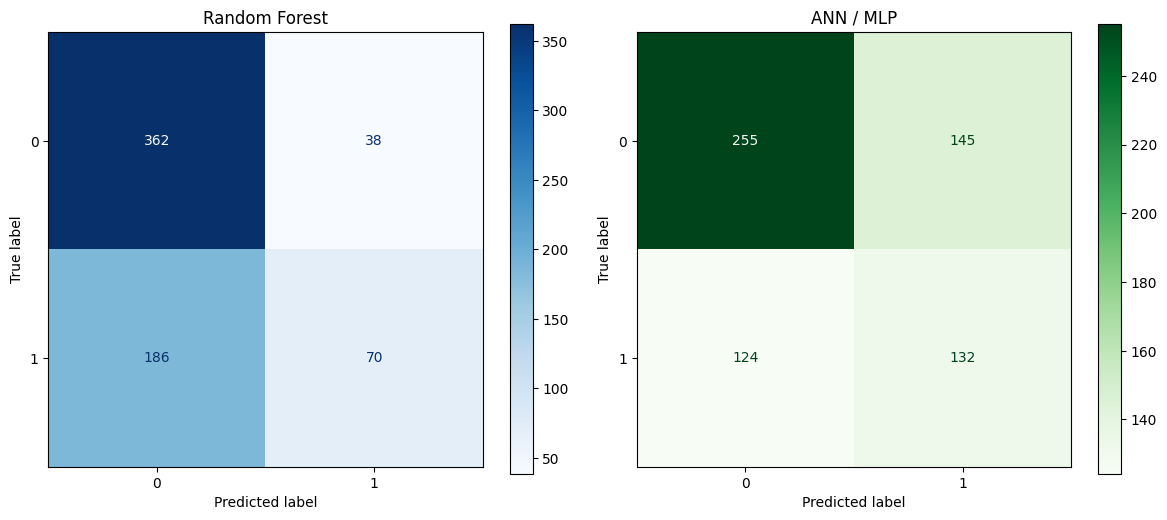

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, cmap="Blues", ax=axes[0])
axes[0].set_title("Random Forest")

ConfusionMatrixDisplay.from_estimator(ann_model, X_test, y_test, cmap="Greens", ax=axes[1])
axes[1].set_title("ANN / MLP")

plt.tight_layout()
plt.show()

Observations:
Random Forest achieved 362 true positives, 186 false positives, 38 false negatives, and 70 true negatives; while ANN got 255 TP, 124 FP, 145 FN, and 132 TN. Random horest had higher accuracy but a lower F1 score due to the recall score.

23. Feature Importance Plot

                  Feature  Importance
4                 Sulfate    0.118083
0                      ph    0.103096
1                Hardness    0.100653
3             Chloramines    0.092042
10    Hardness_to_Sulfate    0.087753
2                  Solids    0.081666
7         Trihalomethanes    0.080162
9   Solids_x_Conductivity    0.079495
5            Conductivity    0.079404
8               Turbidity    0.079095
6          Organic_carbon    0.078667
11              ph_acidic    0.012465
12               ph_basic    0.007418


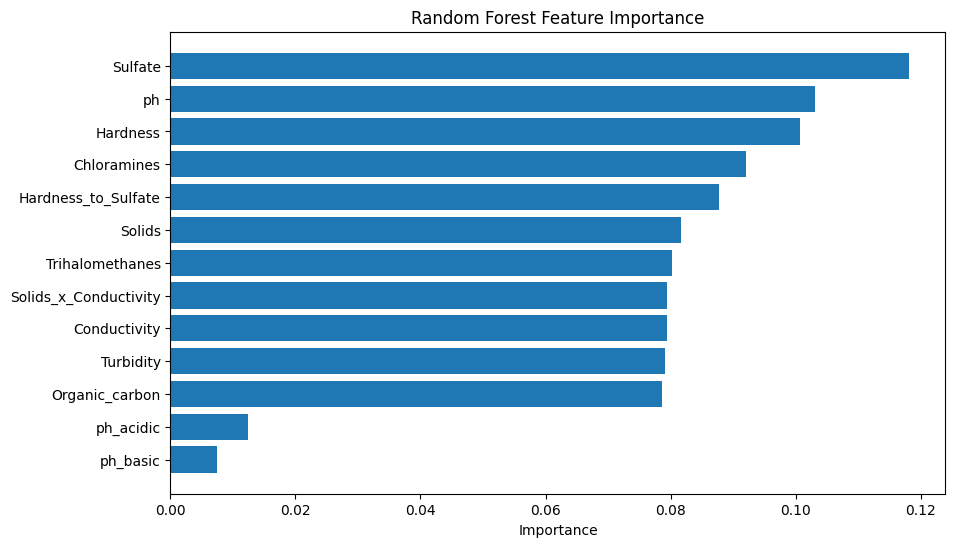

In [ ]:
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': rf_model.feature_importances_})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

plt.figure(figsize=(10,6))
plt.barh(feature_importance['Feature'],
         feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.show()

Observations: Many of the used features had at least 0.08  though certain features like Sulfate, ph, and Hardness reached 0.10 and beyond, with Sulfate being the most used one, indicating those are the most important for the models. pH_acidic and ph_basic have very low importance compared to the rest

ANN/MLP_ Permutation Importance:

                  Feature  Importance
4                 Sulfate    0.039329
1                Hardness    0.032622
0                      ph    0.031860
10    Hardness_to_Sulfate    0.022713
2                  Solids    0.019360
3             Chloramines    0.017988
8               Turbidity    0.005945
9   Solids_x_Conductivity    0.005030
7         Trihalomethanes   -0.002744
6          Organic_carbon   -0.003506
11              ph_acidic   -0.007622
12               ph_basic   -0.008994
5            Conductivity   -0.011128


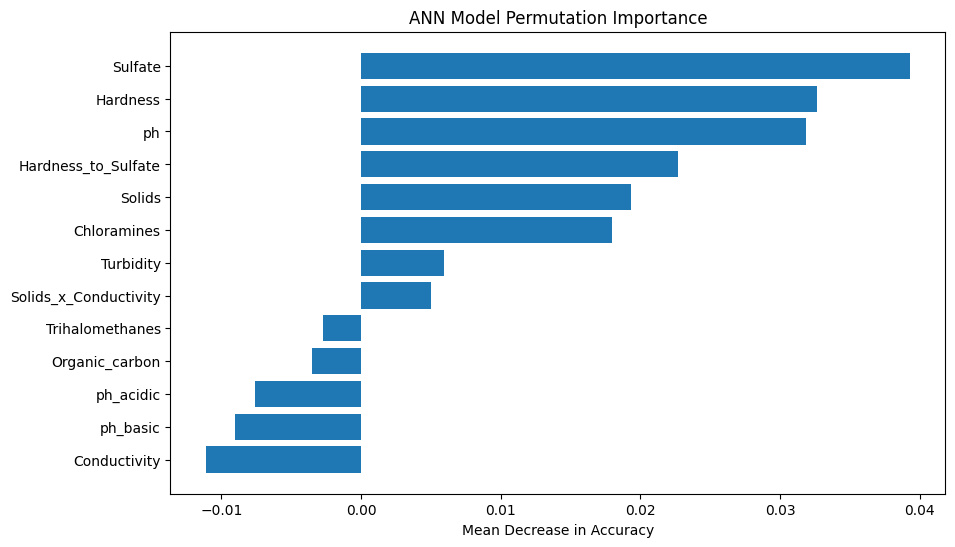

In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(ann_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)

feature_names = X.columns
ann_feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': perm_importance.importances_mean})

# Sort the features by importance in descending order
ann_feature_importance = ann_feature_importance.sort_values(by='Importance', ascending=False)

print("ANN/MLP_ Permutation Importance:\n")
print(ann_feature_importance)

# Plot the feature importance
plt.figure(figsize=(10, 6))
plt.barh(ann_feature_importance['Feature'], ann_feature_importance['Importance'])
plt.gca().invert_yaxis()
plt.title("ANN Model Permutation Importance")
plt.xlabel("Mean Decrease in Accuracy")
plt.show()

24. Plotting the ROC & Learning Curves with Cross Validation

<Figure size 800x600 with 0 Axes>

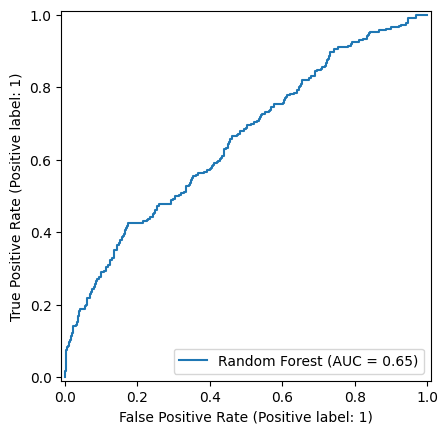

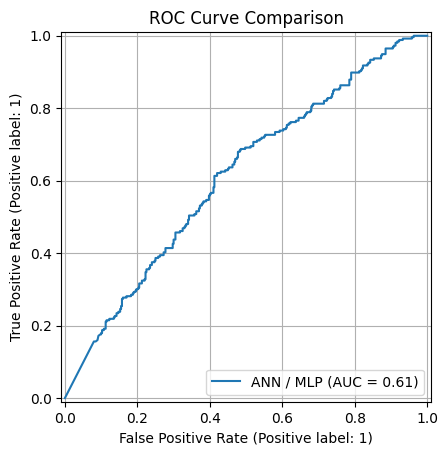

In [ ]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_estimator(rf_model, X_test, y_test, name="Random Forest")

RocCurveDisplay.from_estimator(ann_model, X_test, y_test, name="ANN / MLP")

plt.title("ROC Curve Comparison")
plt.grid(True)
plt.show()

Observations:
Both Random Forest & ANN have similar trends with their ROC curves, with the curves starting at (0, 0) and moving towards (1, 1) which indicates that the False and True Positive Rates increase together. The AUC is the chance in decimal form that the model will rank a randomly chosen positive instance higher than a randomly chosen negative instance, and both 0.65 and 0.61 are better than random guessing. This also supports Random Forest's higher general accuracy.

25. Learning Curve plot

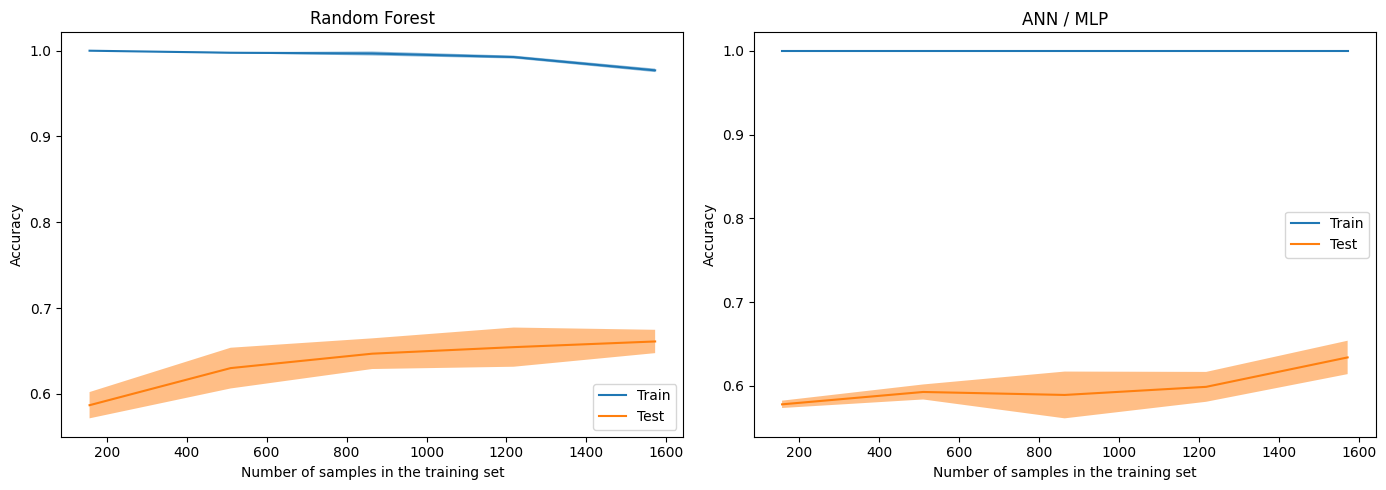

In [ ]:
from sklearn.model_selection import LearningCurveDisplay

fig, axes = plt.subplots(1,2, figsize=(14,5))

LearningCurveDisplay.from_estimator(rf_model, X_train, y_train, cv=5, scoring="accuracy", ax=axes[0])
axes[0].set_title("Random Forest")

LearningCurveDisplay.from_estimator(ann_model, X_train, y_train, cv=5, scoring="accuracy", ax=axes[1])
axes[1].set_title("ANN / MLP")

plt.tight_layout()
plt.show()

Observations:
These learning curves are very interesting as accuracy decreased for training especially for Random Forest, and increased for test with a gap between the two which may indicate some underfitting for training despite generalizing better to unseen test data.

26. Cross Validation Scores

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_models = {"Random Forest": rf_model, "ANN / MLP": ann_model}

cross_val_results = []

for name, model in cross_val_models.items():

    cross_val_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

    cross_val_results.append({"Model": name, "Mean Accuracy": np.mean(cross_val_scores), "Std Dev": np.std(cross_val_scores)})

pd.DataFrame(cross_val_results)

,Model,Mean Accuracy,Std Dev
0,Random Forest,0.661069,0.013598
1,ANN / MLP,0.634097,0.019932


Observations: Using five-fold cross validation, the Random Forest classifier scored a mean accuracy of 66.11% with a standard deviation of 1.36%, indicating consistent performance across different subsets of the dataset. The ANN achieved a mean accuracy of 63.41% with a standard deviation of 1.99%, showing good but slightly more variable performance. Although the Random Forest exhibited greater stability and a higher average accuracy, the ANN achieved the highest F1-score on the independent test set, so the ANN was chosen as the preferred model and the Random Forest was kept for feature importance and comparison.

27. Final Comparison Between Random Forest & Artificial Neural Network

In [ ]:
comparison = pd.DataFrame({

    "Metric":["Accuracy", "Precision", "Recall", "F1 Score"],

    "Random Forest":[0.6585, 0.6481, 0.2734, 0.3846],

    "ANN / MLP":[0.5899, 0.4765, 0.5156, 0.4953]})

print(comparison)

      Metric  Random Forest  ANN / MLP
0   Accuracy         0.6585     0.5899
1  Precision         0.6481     0.4765
2     Recall         0.2734     0.5156
3   F1 Score         0.3846     0.4953


28. Predicting New Water Samples

In [ ]:
#5 Random Samples
for i in range(5):
    rf_pred = rf_model.predict(X_test[i].reshape(1, -1))[0]
    ann_pred = ann_model.predict(X_test[i].reshape(1, -1))[0]

    print(f"Sample {i+1}")
    print(f"Actual: {y_test.iloc[i]}")
    print(f"Random Forest: {rf_pred}")
    print(f"ANN: {ann_pred}")
    print("-" * 25)

Sample 1
Actual: 1
Random Forest: 0
ANN: 0
-------------------------
Sample 2
Actual: 0
Random Forest: 0
ANN: 0
-------------------------
Sample 3
Actual: 0
Random Forest: 0
ANN: 0
-------------------------
Sample 4
Actual: 0
Random Forest: 0
ANN: 1
-------------------------
Sample 5
Actual: 0
Random Forest: 0
ANN: 0
-------------------------


Observations:
Predictions on individual test samples demonstrated the differing behavior of the two models. The Random Forest classifier tended to make more conservative predictions, correctly identifying most non-potable samples but occasionally misclassifying potable water as non-potable. The ANN was more likely to predict potable water, resulting in a higher recall but also a greater number of false positives.